**Import Libraries**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from tqdm.auto import trange
import os
import random


**Parameters for data preprocessing**

In [2]:
# Number of file to pick in both training and development set
# num_files_to_pick = 10000                                                             

### Filepaths MFCC ###
# Training
data_dir = 'D:\\Felipe\\Team Lab\\wav2vec\\wav2vec_train'

# Development/Validation
dev_data_dir = 'D:\\Felipe\\Team Lab\\wav2vec\\wav2vec_dev'


**Preprocessing of training data** 

In [ ]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
features_list = []
labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(data_dir, file_name)
    feature, label = torch.load(file_path)
    feature = feature.squeeze()  # Remove all dimensions of size 1
    features_list.append(feature)
    labels_list.append(label)

# Concatenate all the data into a single tensor
features = torch.stack(features_list)
print("Example of the features",features[1])
labels = torch.tensor(labels_list)
print("Example of the labels",labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", features.shape)
print("Labels shape:", labels.shape)

# Create a TensorDataset and DataLoader
dataset = TensorDataset(features, labels)
dataLoader = DataLoader(dataset, batch_size=64, shuffle=True)
print("The training dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[[[ 0.7106,  0.6576,  0.7385,  ...,  0.7515, -0.0708,  0.3243],
          [ 0.5837,  0.4663,  0.8709,  ...,  0.8026,  0.7496,  0.7424],
          [ 1.1888,  1.0922,  1.8405,  ...,  0.9806,  0.4780,  0.0490],
          ...,
          [ 1.2502,  0.9405, -0.1883,  ...,  0.3727,  0.6997,  0.8640],
          [ 0.7964,  0.7901,  1.3027,  ..., -0.0375,  1.6291,  0.1260],
          [-0.4088, -0.5944,  0.2743,  ..., -0.3642, -1.4540, -0.4494]]]])
Example of the features tensor([[[[ 0.3503, -0.5675,  0.0655,  ..., -0.5427, -0.1047,  0.3718],
          [ 0.3397,  0.2515,  0.4447,  ...,  0.2939,  0.3163,  0.5517],
          [-0.0231, -0.6702, -0.2208,  ..., -0.6623,  0.3215,  1.1146],
          ...,
          [-0.0392,  0.4432,  0.0550,  ...,  0.3689,  0.1078, -0.2921],
          [ 0.5917,  2.5480,  0.6036,  ...,  2.5686,  1.5106,  0.8730],
          [-0.6702, -1.1284, -0.8321,  ..., -1.1063, -0.4853,  0.1733]]]])
Example of the labels tensor([0, 1, 0,  ..., 0, 0, 0

**Dataset inspection**

In [4]:
# Inspect the range of labels in the dataset
#print("Minimum label value:", labels.min().item())
#print("Maximum label value:", labels.max().item())
#print("Unique label values:", torch.unique(labels))

# Inspect the first sample in the batch
print("First sample shape:", features[0].shape)
print("First sample values:\n", features[0])


# Inspect the concatenated tensor
#print("Data Tensor Shape:", data_tensor.shape)
#print("Data Tensor Data Type:", data_tensor.dtype)
#print("Sample Data Tensor Values:\n", data_tensor[:5])  # Print the first 5 rows

# Inspect features and labels
#print("Features Shape:", features.shape)
#print("Labels Shape:", labels.shape)
#print("Sample Features:\n", features[:5])  # Print the first 5 rows of features
print("Sample Labels:\n", labels[:100])  # Print the first 5 labels

First sample shape: torch.Size([1, 1, 768, 199])
First sample values:
 tensor([[[[ 0.7106,  0.6576,  0.7385,  ...,  0.7515, -0.0708,  0.3243],
          [ 0.5837,  0.4663,  0.8709,  ...,  0.8026,  0.7496,  0.7424],
          [ 1.1888,  1.0922,  1.8405,  ...,  0.9806,  0.4780,  0.0490],
          ...,
          [ 1.2502,  0.9405, -0.1883,  ...,  0.3727,  0.6997,  0.8640],
          [ 0.7964,  0.7901,  1.3027,  ..., -0.0375,  1.6291,  0.1260],
          [-0.4088, -0.5944,  0.2743,  ..., -0.3642, -1.4540, -0.4494]]]])
Sample Labels:
 tensor([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0])


**Testing the Data Loader**

In [5]:
print(len(dataset[0][0]))
print(features.shape)

for batch in dataLoader:
    features, labels = batch
    print("Batch features shape:", features.shape)
    break

1
torch.Size([25380, 1, 1, 768, 199])
Batch features shape: torch.Size([64, 1, 1, 768, 199])


**Preprocessing and loading the Development/Validation Set**

In [ ]:
# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(dev_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(dev_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
dev_features_list = []
dev_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(dev_data_dir, file_name)
    dev_feature, dev_label = torch.load(file_path)
    dev_feature = dev_feature.squeeze()  # Remove all singleton dimensions
    dev_features_list.append(dev_feature)  # Append the tensors
    dev_labels_list.append(dev_label) # Append the labels

# Concatenate all the data into a single tensor
dev_features = torch.stack(dev_features_list)
print("Example of the features",dev_features[1])
dev_labels = torch.tensor(dev_labels_list)
print("Example of the labels",dev_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", dev_features.shape)
print("Labels shape:", dev_labels.shape)

# Create a TensorDataset and DataLoader
dev_dataset = TensorDataset(dev_features, dev_labels)
dev_dataLoader = DataLoader(dev_dataset, batch_size=64, shuffle=False)
print("The development dataset has been successfully loaded into DataLoader.")

Example of the .pt file tensor([[[[ 0.7090,  0.4082,  0.5972,  ..., -0.8157, -0.1176,  1.0416],
          [ 0.5864,  0.5273,  0.4272,  ...,  0.3971,  0.7785,  0.6171],
          [ 1.7648,  1.0274,  2.0807,  ...,  0.7132,  1.7719,  1.0086],
          ...,
          [ 0.6174,  0.2577, -1.0611,  ...,  0.0156,  0.2848, -0.5107],
          [ 0.4994,  0.4202,  0.7340,  ...,  1.8209,  0.3415,  0.3481],
          [-0.2305, -0.5465,  0.6370,  ..., -0.8494,  0.2328,  0.1237]]]])
Example of the features tensor([[[[ 0.3665,  0.0382,  0.3772,  ..., -0.1519, -0.3951,  0.0521],
          [ 0.6709,  0.8180,  0.5489,  ...,  0.6268,  0.4538,  0.6849],
          [ 0.8724,  0.4739,  0.0709,  ...,  0.5427,  0.1415,  0.7590],
          ...,
          [ 0.3886,  0.1942,  0.5472,  ...,  1.0585,  0.8884,  0.7240],
          [ 0.8950,  0.4873,  0.7046,  ...,  1.6271,  2.0264,  0.4682],
          [-0.3007, -1.1685, -1.1761,  ..., -0.9116, -1.1451,  0.3385]]]])
Example of the labels tensor([0, 0, 0,  ..., 0, 0, 0

**Testing the Processed Dataloaders and Label Distribution**

In [7]:
print("Training features shape",features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Training labels shape",labels.shape)
print("Development features shape:", dev_features.shape,"[1] batch size | [2] wav2vec Coefficients | [3] Timeframes")
print("Development labels shape:", dev_labels.shape)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training features shape torch.Size([64, 1, 1, 768, 199]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Training labels shape torch.Size([64])
Development features shape: torch.Size([24844, 1, 1, 768, 199]) [1] batch size | [2] wav2vec Coefficients | [3] Timeframes
Development labels shape: torch.Size([24844])
Training label distribution: tensor([58,  6])
Validation label distribution: tensor([22296,  2548])


**Hyperparemeters**

In [8]:
hidden_dim = 128  # Number of neurons in the hidden layer
dropout_prob = 0.5  # Dropout probability

**Neural Network Model**

In [9]:
class SpoofDetectionModel(nn.Module):
    def __init__(self, hidden_dim, dropout_prob=0.5):
        super(SpoofDetectionModel, self).__init__()
        
        # 1D Convolutional layers
        self.conv1 = nn.Conv1d(in_channels=768, out_channels=32, kernel_size=3, stride=1, padding=1) # in channels = LFCC coefficients
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout_prob)
        
        # Fully connected layers
        self.fc1 = None  # Placeholder, will be initialized dynamically
        self.fc3 = nn.Linear(hidden_dim, 1)  # Single output neuron for binary classification
        
        # Initialize weights
        self.init_weights()
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d) or isinstance(m, nn.Linear):
                torch.nn.init.kaiming_uniform_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)
        
    def forward(self, x):
        # Input x is already (batch_size, num_channels, sequence_length) for MFCC: [batch, 40, 126]
        
        # Convolutional layers
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.dropout(x)  # Apply dropout after convolutional layers
        
        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)
        
        # Dynamically initialize fc1 if not already done
        if self.fc1 is None:
            self.fc1 = nn.Linear(x.size(1), hidden_dim).to(x.device)
        
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)  # Apply dropout after the first fully connected layer
        x = self.fc3(x)  # Output layer: Sigmoid for binary classification / previous line (before BCEwithLogits): x = torch.sigmoid(self.fc3(x))
        
        return x

**Initializing the model**

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = SpoofDetectionModel(hidden_dim, dropout_prob).to(device)

**Calculate the weights proportion for weighted loss**

In [11]:
'''Formula: weight_for_class_i = total_samples / (num_samples_in_class_i * num_classes)

print("Training label distribution:", torch.bincount(labels))
print("Validation label distribution:", torch.bincount(dev_labels))

Training label distribution: tensor([26,  6])
Validation label distribution: tensor([8949, 1051])
'''

# Proportion of samples of the development set
counts = torch.bincount(dev_labels) # tensor with [SPOOF, BONAFIDE]
proportions = counts / len(dev_labels) * 100
prop_spoof = float(proportions[0])
prop_bonafide = float(proportions[1])
print("Proportion of the Development Set:\n",f"Spoof: {prop_spoof:.2f}% | Bonafide: {prop_bonafide:.2f}%")


weight_for_class_0 = (len(dev_labels) / (torch.bincount(dev_labels)[0] * 2))
print("Weight of class 0 (spoof):",weight_for_class_0)

weight_for_class_1 = (len(dev_labels) / (torch.bincount(dev_labels)[1] * 2))
print("Weight of class 1 (bonafide):",weight_for_class_1)

weighted_loss_pos = torch.tensor(weight_for_class_1)
print("Weight tensor to be passed to the Loss Function",weighted_loss_pos)

Proportion of the Development Set:
 Spoof: 89.74% | Bonafide: 10.26%
Weight of class 0 (spoof): tensor(0.5571)
Weight of class 1 (bonafide): tensor(4.8752)
Weight tensor to be passed to the Loss Function tensor(4.8752)


C:\Users\fnobrega\AppData\Local\Temp\ipykernel_19240\4247703482.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weighted_loss_pos = torch.tensor(weight_for_class_1)


**Loss function and Optimizer**

In [12]:
criterion = nn.BCEWithLogitsLoss(pos_weight=weighted_loss_pos)  # Binary cross-entropy loss
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)  # Learning rate + weight decay

**Metric Initialization / Learning Scheduler / Early stopping**

In [13]:
import matplotlib.pyplot as plt

# Initialize lists to store metrics
losses_train = [] # Stores the average training loss for each epoch.
losses_val = [] # Stores the average validation loss for each epoch.
accuracies_train = [] # Stores the training accuracy for each epoch.
accuracies_val = [] # Stores the validation accuracy for each epoch.
eers_val = []

### Learning rate scheduler to reduce the learning rate during training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

# Initialize variables for early stopping
best_eer = float('inf')  # Track the best validation loss
patience = 10  # Number of epochs to wait for improvement
counter = 0   # Counter for early stopping



**Training Loop**

In [16]:
import numpy as np
from sklearn.metrics import roc_curve, f1_score
from scipy.special import expit  # sigmoid function
# Training loop
num_epochs = 100

def calculate_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    return eer * 100, thresholds[eer_idx]

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss_train = 0.0
    correct_train = 0
    total_train = 0

    # Training phase
    for batch_idx, (features, labels) in enumerate(dataLoader):
        features, labels = features.to(device), labels.to(device) #for LFCC -> old code, possibly for wav2vec: features, labels = features.unsqueeze(1).to(device), labels.to(device)
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels.float().unsqueeze(1))  # Reshape labels to [batch_size, 1]

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate training loss and accuracy
        epoch_loss_train += loss.item()
        predicted = (outputs > 0).float()
        total_train += labels.size(0)
        correct_train += (predicted.squeeze() == labels).sum().item()

    # Compute average training loss and accuracy for the epoch
    avg_loss_train = epoch_loss_train / len(dataLoader)
    accuracy_train = 100 * correct_train / total_train
    losses_train.append(avg_loss_train)
    accuracies_train.append(accuracy_train)

    # -------- VALIDATION PHASE + EER --------
    model.eval()
    epoch_loss_val = 0.0
    correct_val = 0
    total_val = 0
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dev_dataLoader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1)) # Reshape labels to [batch_size, 1]

            # Accumulate validation loss and accuracy
            epoch_loss_val += loss.item()
            predicted = (outputs > 0).float()
            correct_val += (predicted.squeeze() == labels).sum().item()
            total_val += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Compute average validation loss and accuracy for the epoch
    avg_loss_val = epoch_loss_val / len(dev_dataLoader)
    accuracy_val = 100 * correct_val / total_val
    losses_val.append(avg_loss_val)
    accuracies_val.append(accuracy_val)

    # --- Calculate EER on validation set ---
    eer_val, threshold_val = calculate_eer(np.array(all_labels), np.array(all_scores))
    eers_val.append(eer_val)

    # Print metrics
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {avg_loss_train:.4f}, Acc: {accuracy_train:.2f}% | "
          f"Val Loss: {avg_loss_val:.4f}, Acc: {accuracy_val:.2f}% | "
          f"Val EER: {eer_val:.2f}%")

    # Learning rate scheduling
    scheduler.step(avg_loss_val)

    # --- Early Stopping Based on Validation EER ---
    if eer_val < best_eer:
        best_eer = eer_val
        counter = 0
    else:
        counter += 1
        print(f"EER not improved. Patience counter: {counter}/{patience}")
        if counter >= patience and epoch >= 10:
            torch.save(model.state_dict(), 'wav2vec_best_model.pth')
            print("Early stopping triggered (EER did not improve).")
            break


RuntimeError: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [64, 1, 1, 768, 199]

**Plotting the results**

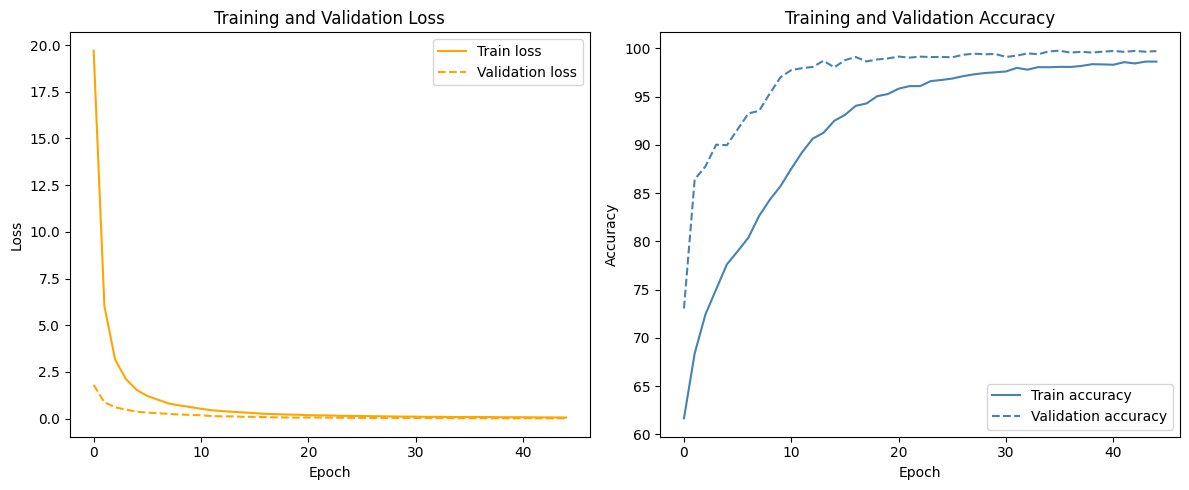

In [13]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(losses_train, color="orange", linestyle="-", label="Train loss")
plt.plot(losses_val, color="orange", linestyle="--", label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(accuracies_train, color="steelblue", linestyle="-", label="Train accuracy")
plt.plot(accuracies_val, color="steelblue", linestyle="--", label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

**Saving the model**

In [ ]:
torch.save(model.state_dict(), 'lfcc_updated_model_deepfake_audio_detection_model.pth')

**Prepare Evaluation Dataset**

In [14]:
# Evaluation
eval_data_dir = 'C:\\Users\\felip\\teamlab-phonetics\\feature_extraction\\lfcc_segment_outputs\\lfcc_eval'

# Set the number of files to pick and the random seed
#random_seed = 42

# List all .pt files in the directory
all_files = [f for f in os.listdir(eval_data_dir) if f.endswith('.pt')]

# Set the random seed for reproducibility
#random.seed(random_seed)

# Randomly select the specified number of files
# selected_files = random.sample(all_files, num_files_to_pick)

# Inspect a single .pt file before loading into classes
inspect_file = os.path.join(eval_data_dir, all_files[0])  # Select the first file from the random selection

# Inspect the data from the .pt file
inspect_data = torch.load(inspect_file)
print("Example of the .pt file",inspect_data[0])

# Initialize a list to store the features and labels
eval_features_list = []
eval_labels_list = []

# Load the features and labels for the selected .pt files
for file_name in all_files:
    file_path = os.path.join(eval_data_dir, file_name)
    eval_feature, eval_label = torch.load(file_path)
    eval_features_list.append(eval_feature)  # Append the tensors
    eval_labels_list.append(eval_label) # Append the labels

# Concatenate all the data into a single tensor
eval_features = torch.stack(eval_features_list)
print("Example of the features",eval_features[1])
eval_labels = torch.tensor(eval_labels_list)
print("Example of the labels",eval_labels)

# Debugging: Check the shapes of features and labels
print("Features shape:", eval_features.shape)
print("Labels shape:", eval_labels.shape)

# Create a TensorDataset and DataLoader
eval_dataset = TensorDataset(eval_features, eval_labels)
eval_dataLoader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
print("The evaluation dataset has been successfully loaded into DataLoader.")


Example of the .pt file tensor([[-3.1719e+02, -1.8039e+02, -6.8076e+01,  ..., -4.5134e+01,
         -3.8520e+01, -1.7389e+01],
        [ 8.4354e+01,  1.6613e+02,  2.0741e+02,  ...,  2.5119e+02,
          2.3634e+02,  2.3194e+02],
        [ 4.2919e+01,  3.2076e+01,  1.4553e+01,  ..., -4.7070e+00,
         -1.9970e+00, -8.4831e-02],
        ...,
        [-5.3541e-01, -4.2967e+00, -4.6846e+00,  ..., -2.6436e+00,
          2.1220e+00,  2.2705e+00],
        [-2.7110e+00, -2.6688e+00,  3.9215e-01,  ...,  3.3957e-01,
         -1.4249e+00, -1.3578e+00],
        [ 4.4136e+00,  1.6556e+00,  2.2209e+00,  ...,  3.5947e-01,
          1.9454e+00,  1.6566e+00]])
Example of the features tensor([[-3.3888e+02, -3.7314e+02, -2.9060e+02,  ..., -3.8714e+02,
         -3.9049e+02, -3.9146e+02],
        [ 3.6489e+01,  3.1510e+01,  9.5408e+01,  ...,  2.2135e+01,
          1.7525e+01,  1.6173e+01],
        [ 1.3734e+01,  1.6058e+01,  4.1746e+01,  ...,  2.1536e+01,
          1.7273e+01,  1.5978e+01],
        ...

In [ ]:
def evaluate_on_eval_set(model, eval_dataLoader):
    model.eval()
    all_scores = []
    all_labels = []
    total = 0
    correct = 0
    total_loss = 0.0

    with torch.no_grad():
        for features, labels in eval_dataLoader:
            features, labels = features.to(device), labels.to(device) #change it to unsqueeze if using wav2vec
            outputs = model(features)
            loss = criterion(outputs, labels.float().unsqueeze(1))

            total_loss += loss.item()
            predicted = (outputs > 0).float()
            correct += (predicted.squeeze() == labels).sum().item()
            total += labels.size(0)

            all_scores.extend(outputs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy())

    # Metrics
    avg_loss = total_loss / len(eval_dataLoader)
    accuracy = 100 * correct / total
    eer, threshold = calculate_eer(np.array(all_labels), np.array(all_scores))
    prob_threshold = expit(threshold)
    preds = (np.array(all_scores) >= threshold).astype(int)
    f1 = f1_score(np.array(all_labels), preds)

    # Print results
    print(f"\nEvaluation Set:")
    print(f"Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")
    print(f"EER: {eer:.2f}% | Logit Threshold: {threshold:.4f} | Prob Threshold: {prob_threshold:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Predictions: [1]: {np.count_nonzero(preds == 1)} | [0]: {np.count_nonzero(preds == 0)}")

evaluate_on_eval_set(model, eval_dataLoader)


Evaluation Set:
Loss: 1.2715 | Accuracy: 57.20%
EER: 11.58% | Logit Threshold: 3.9547 | Prob Threshold: 0.9812
F1 Score: 0.6118
Predictions: [1]: 13902 | [0]: 57335
